# Heart Disease Prediction Analysis
**Dataset:** UCI Heart Disease Repository (920 rows, 14 features)  
**Goal:** To develop a predictive model that assists in the early detection of heart disease, potentially improving patient outcomes through early detection. (Whether a patient has heart disease (binary: Yes / No))

**Models:**
* Logistic Regression
* Decision Tree
* Random Forest

**Metrics:**
* Accuracy
* Precision
* Recall
* F1-Score
* ROC-AUC

### Data Dictionary (Variables Table)

| Variable | Name | Description |
| :--- | :--- | :--- |
| **age** | Age | Age in years |
| **sex** | Sex | 1 = male; 0 = female |
| **cp** | Chest Pain Type | 1: typical angina, 2: atypical angina, 3: non-anginal pain, 4: asymptomatic |
| **trestbps** | Resting Blood Pressure | Resting blood pressure (in mm Hg on admission to the hospital) |
| **chol** | Serum Cholestoral | Serum cholestoral in mg/dl |
| **fbs** | Fasting Blood Sugar | > 120 mg/dl (1 = true; 0 = false) |
| **restecg** | Resting ECG | 0: normal, 1: ST-T wave abnormality, 2: left ventricular hypertrophy |
| **thalach** | Max Heart Rate | Maximum heart rate achieved |
| **exang** | Exercise Angina | Exercise induced angina (1 = yes; 0 = no) |
| **oldpeak** | ST Depression | ST depression induced by exercise relative to rest |
| **slope** | ST Slope | Slope of the peak exercise ST segment (1: upsloping, 2: flat, 3: downsloping) |
| **ca** | Major Vessels | Number of major vessels (0-3) colored by flourosopy |
| **thal** | Thalassemia | 3 = normal; 6 = fixed defect; 7 = reversable defect |
| **target** | Diagnosis | Angiographic disease status (0: < 50% diameter narrowing, 1: > 50%) |

Install & Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests, io

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score
)

## I. Load and Inspect Data

In [ ]:
##Data source: Janosi et al. (1988). UCI Machine Learning Repository
#Define the source locations and respective URLs
data_sources = {
    "cleveland": "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data",
    "hungary": "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.hungarian.data",
    "switzerland": "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.switzerland.data",
    "va_long_beach": "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.va.data"
}

#Define the standard 14 column names - provided in the UCI site
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

all_dfs = []

#Loop to download source data from each URL
for city, url in data_sources.items():
    response = requests.get(url)
    #na_values="?" is used as UCI uses '?' for missing data
    df = pd.read_csv(io.StringIO(response.text), names=columns, na_values="?")

    #Add 'location' column to indicate city of cource data
    df['location'] = city
    all_dfs.append(df)

#Combine into one large DataFrame
df = pd.concat(all_dfs, ignore_index=True)

#Quick check of the results
print(f'Dataset shape: {df.shape}')
print(df.groupby('location').size())
df.head()

Dataset shape: (920, 15)
location
cleveland        303
hungary          294
switzerland      123
va_long_beach    200
dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,location
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,cleveland


In [ ]:
#Check data types and missing values
print(df.info())
#Get statistical summary
print(df.describe())
#Analysis of Sick vs Healthy
print(df['target'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    float64
 1   sex       920 non-null    float64
 2   cp        920 non-null    float64
 3   trestbps  861 non-null    float64
 4   chol      890 non-null    float64
 5   fbs       830 non-null    float64
 6   restecg   918 non-null    float64
 7   thalach   865 non-null    float64
 8   exang     865 non-null    float64
 9   oldpeak   858 non-null    float64
 10  slope     611 non-null    float64
 11  ca        309 non-null    float64
 12  thal      434 non-null    float64
 13  target    920 non-null    int64  
 14  location  920 non-null    object 
dtypes: float64(13), int64(1), object(1)
memory usage: 107.9+ KB
None
              age         sex          cp    trestbps        chol         fbs  \
count  920.000000  920.000000  920.000000  861.000000  890.000000  830.000000   


In [ ]:
#Review of Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('Columns with missing values:')
print(missing_df)

Columns with missing values:
          Missing Count  Missing %
ca                  611       66.4
thal                486       52.8
slope               309       33.6
fbs                  90        9.8
oldpeak              62        6.7
trestbps             59        6.4
exang                55        6.0
thalach              55        6.0
chol                 30        3.3
restecg               2        0.2


## II. Exploratory Data Analysis (EDA)

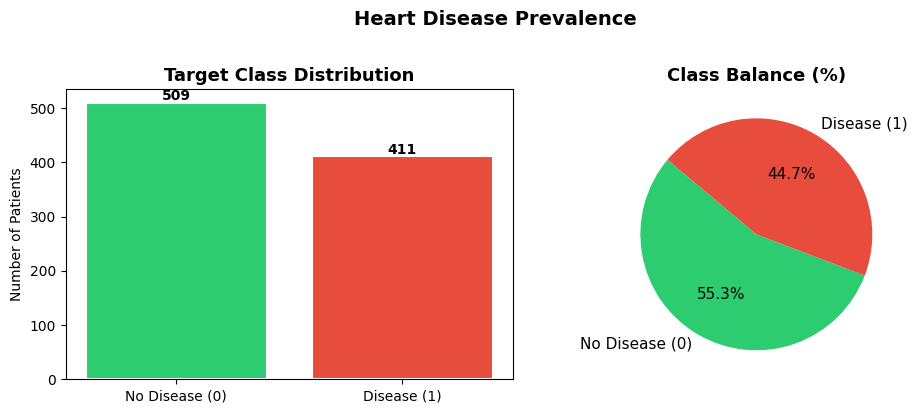

In [ ]:
#Binary conversion approach consistent with Kiuchi et al. (2024)
#Convert target column (0-4 values) to binary (0=no disease, 1=disease)
df['heart_disease'] = (df['target'] > 0).astype(int)
counts = df['heart_disease'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

#Generate Bar chart for analysis
axes[0].bar(['No Disease (0)', 'Disease (1)'], counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Target Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

#Generate Pie chart for analysis
axes[1].pie(counts.values, labels=['No Disease (0)', 'Disease (1)'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
            startangle=140, textprops={'fontsize': 11})
axes[1].set_title('Class Balance (%)', fontsize=13, fontweight='bold')

plt.suptitle('Heart Disease Prevalence', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

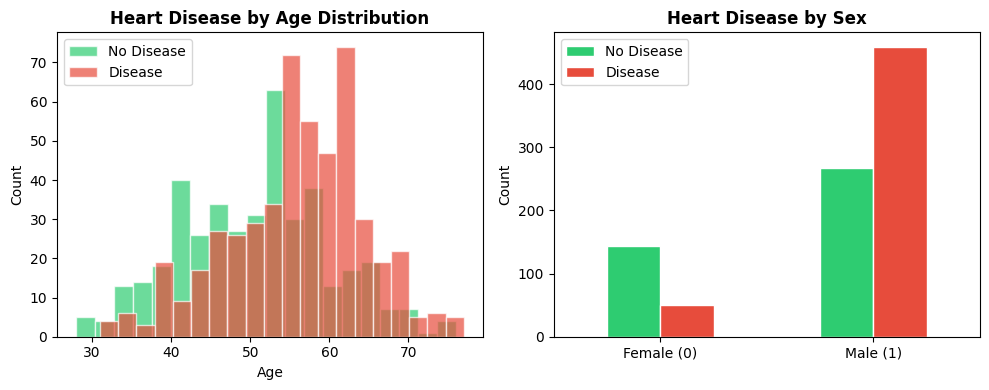

In [ ]:
#Age and Sex distribution by Heart Disease outcome
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

#Generate Age histogram for analysis
for label, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
    axes[0].hist(df[df['heart_disease'] == label]['age'], bins=20,
                 alpha=0.7, color=color, label=['No Disease','Disease'][label], edgecolor='white')
axes[0].set_title('Heart Disease by Age Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

#Generate Sex stacked bar for analysis
sex_disease = df.groupby(['sex', 'heart_disease']).size().unstack(fill_value=0)
sex_disease.index = ['Female (0)', 'Male (1)']
sex_disease.columns = ['No Disease', 'Disease']
sex_disease.plot(kind='bar', ax=axes[1], color=['#2ecc71','#e74c3c'],
                 edgecolor='white', rot=0)
axes[1].set_title('Heart Disease by Sex', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

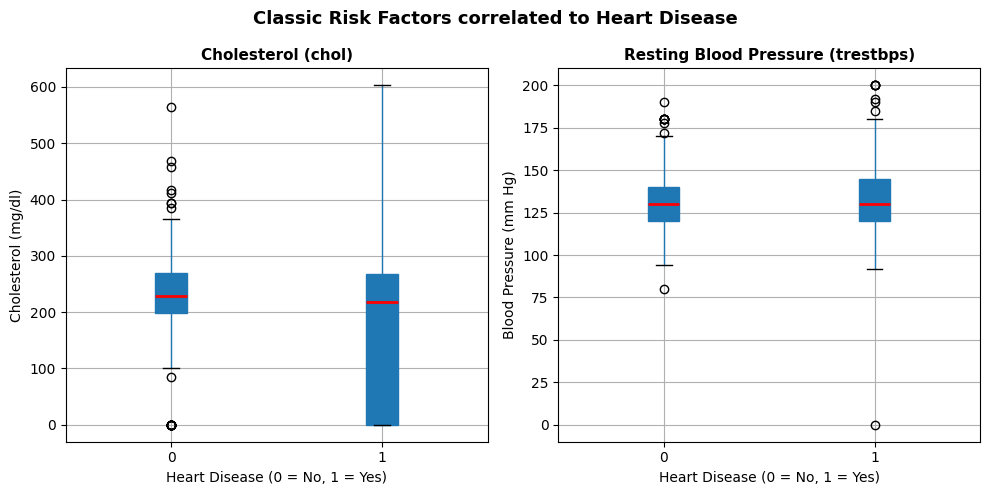

In [ ]:
#Analysis of common risk factors for heart diseases

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

#Cholesterol
df.boxplot(column='chol', by='heart_disease', ax=axes[0],
           medianprops=dict(color='red', linewidth=2), patch_artist=True)
axes[0].set_title('Cholesterol (chol)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Heart Disease (0 = No, 1 = Yes)')
axes[0].set_ylabel('Cholesterol (mg/dl)')

#Resting blood pressure
df.boxplot(column='trestbps', by='heart_disease', ax=axes[1],
           medianprops=dict(color='red', linewidth=2), patch_artist=True)
axes[1].set_title('Resting Blood Pressure (trestbps)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Heart Disease (0 = No, 1 = Yes)')
axes[1].set_ylabel('Blood Pressure (mm Hg)')

plt.suptitle('Classic Risk Factors correlated to Heart Disease',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

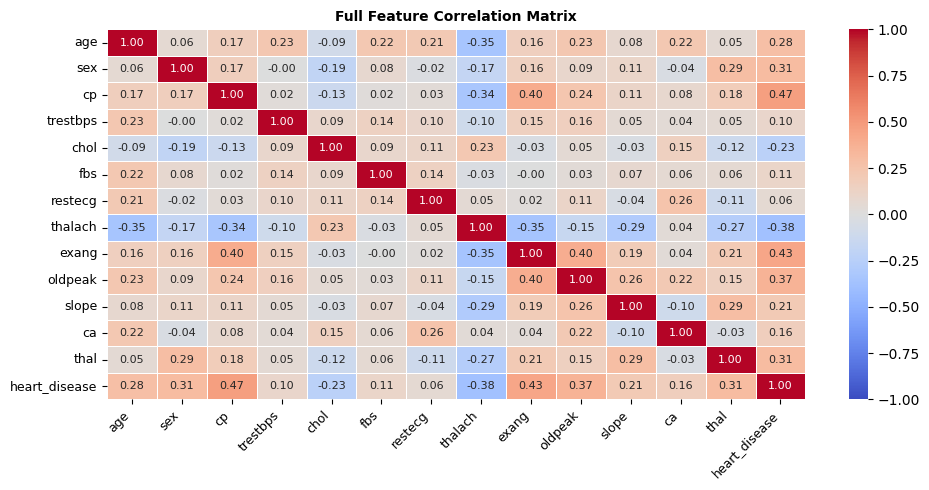

Features ranked by correlation with heart disease (strongest first):
cp          0.472
exang       0.434
thalach     0.382
oldpeak     0.366
thal        0.312
sex         0.307
age         0.283
chol        0.229
slope       0.205
ca          0.165
fbs         0.108
trestbps    0.101
restecg     0.062
Name: heart_disease, dtype: float64


In [ ]:
#Correlation heatmap to analyze feature importance
#Temporary copy for correlation calculation only (df remains unchanged for rest of EDA)
df_corr = df.copy()
#(Note: ca, thal, slope will be median-imputed here for EDA purposes only)
df_corr = df_corr.fillna(df_corr.median(numeric_only=True))
df_corr = pd.get_dummies(df_corr, drop_first=True)

#Drop target column
df_corr = df_corr.drop(columns=['target'], errors='ignore')

location_cols = [c for c in df_corr.columns if c.startswith('location_')]
df_corr = df_corr.drop(columns=location_cols, errors='ignore')

corr_matrix = df_corr.corr()

plt.figure(figsize=(10, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 8},
    vmin=-1, vmax=1
)
plt.title('Full Feature Correlation Matrix', fontsize=10, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

#Ranked list
top_features = (corr_matrix['heart_disease']
                .drop('heart_disease')
                .abs()
                .sort_values(ascending=False))

print("Features ranked by correlation with heart disease (strongest first):")
print(top_features.round(3))

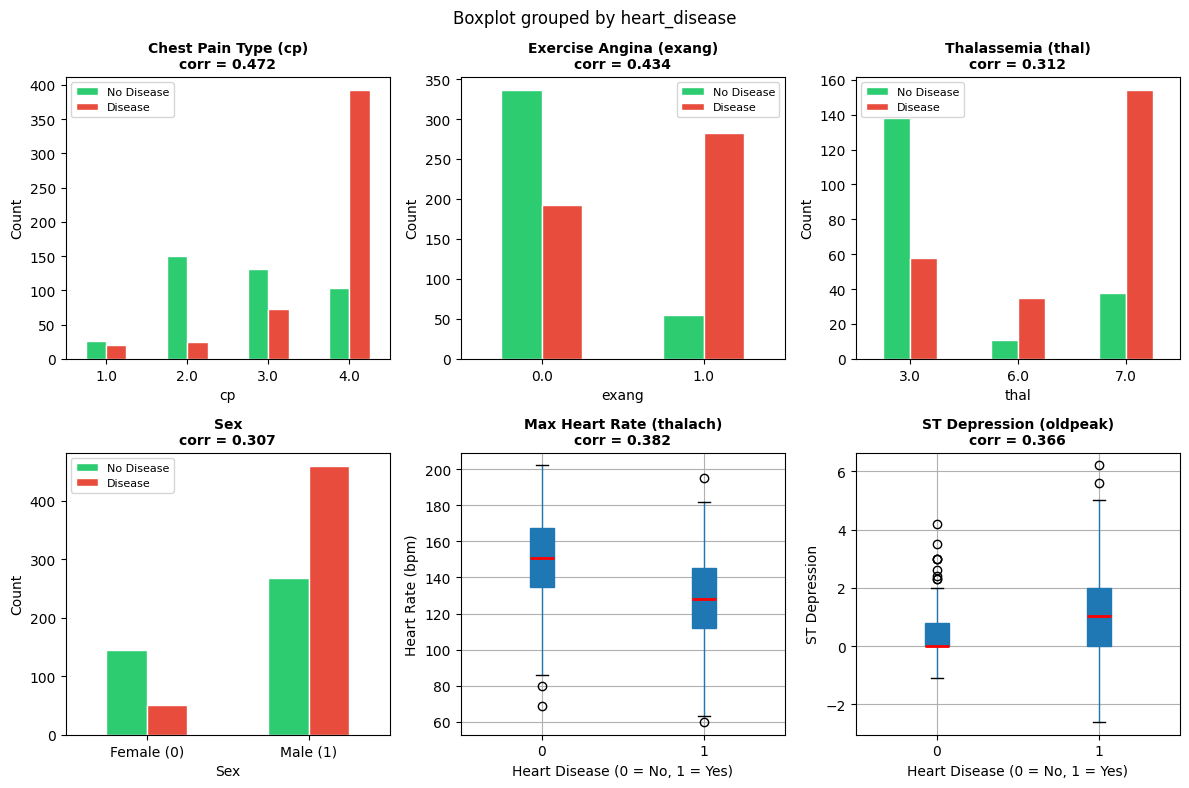

In [ ]:
#Analyze categorical (bar chart) and continuous(boxplot)
#Features with correlation >= 0.30 (cp, exang, thalach, oldpeak, thal, sex)
#Categorical: cp, exang, thal, sex
#Continuous: thalach, oldpeak

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Top 6 Predictors Identified by Correlation Analysis (corr ≥ 0.30)',
             fontsize=14, fontweight='bold')

#Top 3 categorical (Row1)
categorical_row1 = [
    ('cp',    'Chest Pain Type (cp)\ncorr = 0.472'),
    ('exang', 'Exercise Angina (exang)\ncorr = 0.434'),
    ('thal',  'Thalassemia (thal)\ncorr = 0.312'),
]

for i, (col, title) in enumerate(categorical_row1):
    counts = df.groupby([col, 'heart_disease']).size().unstack(fill_value=0)
    counts.columns = ['No Disease', 'Disease']
    counts.plot(kind='bar', ax=axes[0, i], color=['#2ecc71', '#e74c3c'],
                edgecolor='white', rot=0)
    axes[0, i].set_title(title, fontsize=10, fontweight='bold')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Count')
    axes[0, i].legend(fontsize=8)

#Row2
sex_counts = df.groupby(['sex', 'heart_disease']).size().unstack(fill_value=0)
sex_counts.index = ['Female (0)', 'Male (1)']
sex_counts.columns = ['No Disease', 'Disease']
sex_counts.plot(kind='bar', ax=axes[1, 0], color=['#2ecc71', '#e74c3c'],
                edgecolor='white', rot=0)
axes[1, 0].set_title('Sex\ncorr = 0.307', fontsize=10, fontweight='bold')
axes[1, 0].set_xlabel('Sex')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend(fontsize=8)

#thalach Boxplot
df.boxplot(column='thalach', by='heart_disease', ax=axes[1, 1],
           medianprops=dict(color='red', linewidth=2), patch_artist=True)
axes[1, 1].set_title('Max Heart Rate (thalach)\ncorr = 0.382', fontsize=10, fontweight='bold')
axes[1, 1].set_xlabel('Heart Disease (0 = No, 1 = Yes)')
axes[1, 1].set_ylabel('Heart Rate (bpm)')

#oldpeak boxplot
df.boxplot(column='oldpeak', by='heart_disease', ax=axes[1, 2],
           medianprops=dict(color='red', linewidth=2), patch_artist=True)
axes[1, 2].set_title('ST Depression (oldpeak)\ncorr = 0.366', fontsize=10, fontweight='bold')
axes[1, 2].set_xlabel('Heart Disease (0 = No, 1 = Yes)')
axes[1, 2].set_ylabel('ST Depression')

plt.tight_layout()
plt.show()

## III. Data Cleaning & Preprocessing


In [ ]:
#Drop non-clinical columns
df = df.drop(columns=['location', 'target'], errors='ignore')
#'location' = where data was collected, not a patient attribute
#'target'= already converted to binary 'heart_disease' column during EDA

print(f"Columns remaining: {list(df.columns)}")

Columns remaining: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'heart_disease']


In [ ]:
#Handling Missing Values
#Two strategies based on missing rate:
#High missing % (ca, thal, slope) - Random Forest imputation
#Low missing  % (trestbps, chol, fbs, restecg, thalach, exang, oldpeak) - Median imputation

print("Missing values before:")
print(df.isnull().sum()[df.isnull().sum() > 0])

#Median imputation for low-missing features
#used median instead of mean which is appropriate for clinical features like chol and trestbps
#tend to be skewed, and median is resistant to extreme values
median_cols = ['trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak']
for col in median_cols:
    df[col] = df[col].fillna(df[col].median())

#Random Forest imputation for high-missing features
#Uses all non-missing rows to train a classifier that predicts missing values
#This is more accurate than median when missing values percentage is high (ca-66%, thal-53%)
rf_impute_cols = ['ca', 'thal', 'slope']

for target_col in rf_impute_cols:
    known   = df[df[target_col].notna()]
    unknown = df[df[target_col].isna()]

    if unknown.empty:
        continue

    feature_cols = [c for c in df.select_dtypes(include=np.number).columns
                    if c != target_col and c != 'heart_disease']

    X_train_imp = known[feature_cols].fillna(known[feature_cols].median())
    X_pred_imp  = unknown[feature_cols].fillna(known[feature_cols].median())
    y_train_imp = known[target_col]

    rf_imp = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_imp.fit(X_train_imp, y_train_imp)
    df.loc[df[target_col].isna(), target_col] = rf_imp.predict(X_pred_imp)

print(f"\nMissing values after: {df.isnull().sum().sum()}")
print("\nImputation strategy used:")
print(f"  Median        : {median_cols}")
print(f"  Random Forest : {rf_impute_cols}")

Missing values before:
trestbps     59
chol         30
fbs          90
restecg       2
thalach      55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
dtype: int64

Missing values after: 0

Imputation strategy used:
  Median        : ['trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak']
  Random Forest : ['ca', 'thal', 'slope']


In [ ]:
#Encode categorical variables
#drop_first=True avoids the dummy variable trap (multicollinearity)

cat_cols = df.select_dtypes(include='object').columns.tolist()
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f"Text columns found: {cat_cols}")
print(f"Shape after encoding: {df.shape}")

Text columns found: []
Shape after encoding: (920, 14)


In [ ]:
#Define X and Y to isolate target attribute (heart_disease)
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

print(f"Features (X): {X.shape[1]} columns, {X.shape[0]} rows")
print(f"Target  (y): {y.value_counts().to_dict()}")

Features (X): 13 columns, 920 rows
Target  (y): {1: 509, 0: 411}


In [ ]:
#Split Train and Test Data
#stratify=y keeps the same disease/healthy ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

Training samples : 736
Testing  samples : 184


In [ ]:
#Scale Features for modeling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## IV. Training Models

**Models:**
* Logistic Regression
* Decision Tree
* Random Forest

In [ ]:
#Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

#Model 2: Decision Tree
#max_depth=5 prevents overfitting (memorising the training data)
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

#Model 3: Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=10,
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print('Training Models completed.')

Training Models completed.


## V. Evaluate Model Performance





### *   Single Split



In [ ]:
#Create function to evaluate all models
def evaluate_model(name, model, X_te, y_te):
    """Returns a dict with all evaluation metrics."""
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]  #probability of class 1
    return {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall'   : recall_score(y_te, y_pred),
        'F1-Score' : f1_score(y_te, y_pred),
        'ROC-AUC'  : roc_auc_score(y_te, y_prob),
        '_y_pred'  : y_pred,
        '_y_prob'  : y_prob
    }

results = [
    evaluate_model('Logistic Regression', lr, X_test_scaled, y_test),
    evaluate_model('Decision Tree',       dt, X_test,        y_test),
    evaluate_model('Random Forest',       rf, X_test,        y_test),
]

#Refine table
metric_cols = ['Model','Accuracy','Precision','Recall','F1-Score','ROC-AUC']
results_df = pd.DataFrame(results)[metric_cols]
results_df.set_index('Model', inplace=True)
results_df = results_df.map(lambda x: f'{x:.4f}')

print('MODEL PERFORMANCE COMPARISON')
results_df

MODEL PERFORMANCE COMPARISON


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8315,0.8381,0.8627,0.8502,0.9035
Decision Tree,0.7717,0.7727,0.8333,0.8019,0.8535
Random Forest,0.8370,0.8333,0.8824,0.8571,0.9164


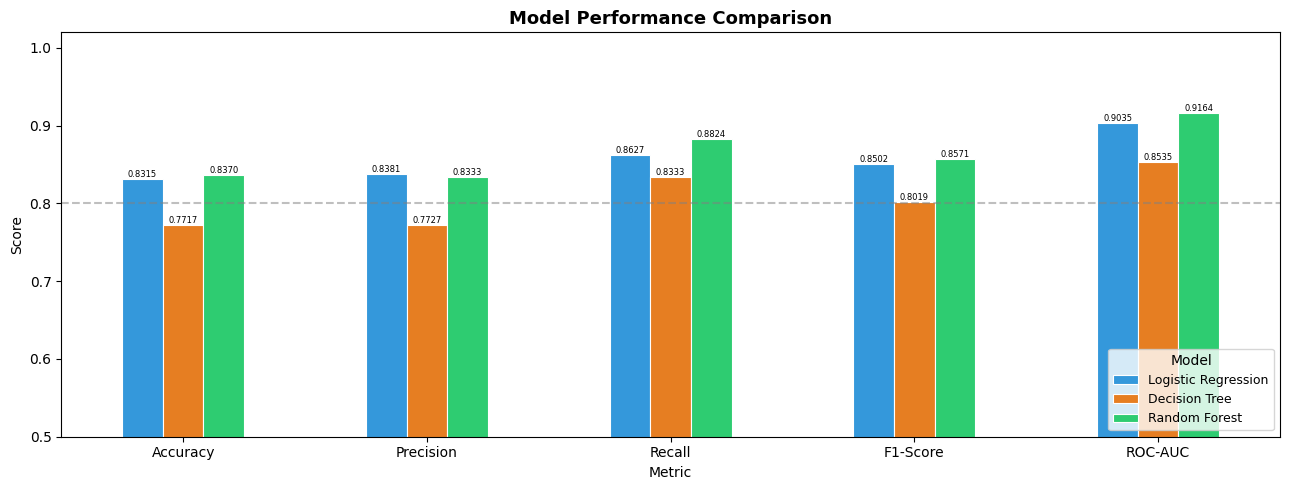

In [ ]:
#Metric bar chart comparison
metric_cols_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
plot_df = pd.DataFrame(results)[['Model'] + metric_cols_plot].set_index('Model')
plot_df = plot_df.astype(float)

#Transpose so metrics are on x-axis and models are grouped bars
ax = plot_df.T.plot(kind='bar', figsize=(13, 5), rot=0,
                    color=['#3498db', '#e67e22', '#2ecc71'],
                    edgecolor='white', linewidth=0.8)

ax.set_ylim(0.5, 1.02)
ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xlabel('Metric')
ax.legend(title='Model', loc='lower right', fontsize=9)
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5)

#Add value labels on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=6)

plt.tight_layout()
plt.show()

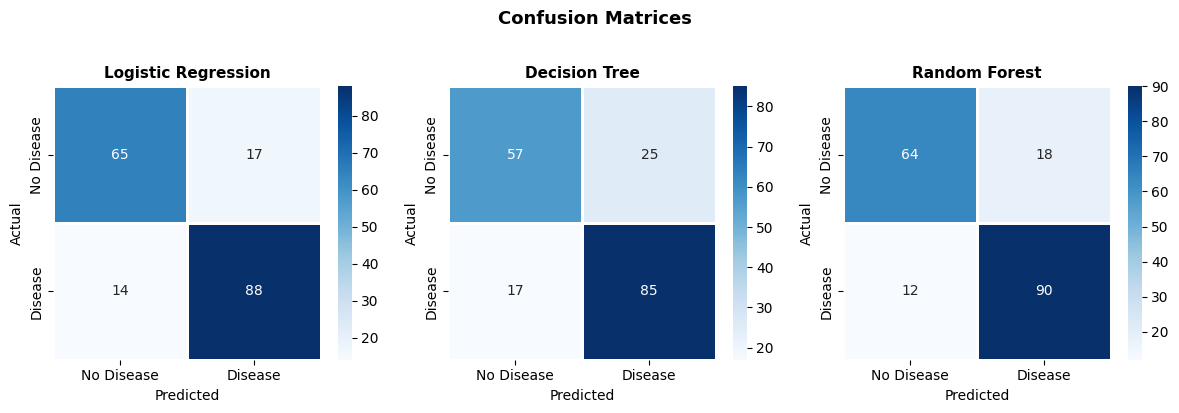


Reading the confusion matrix:
  Top-left  (TN): Correctly predicted NO disease
  Top-right (FP): Predicted disease, but patient is HEALTHY (False alarm)
  Bottom-left(FN): Predicted healthy, but patient HAS disease (Missed Diagnosis)
  Bottom-right(TP): Correctly predicted disease

FALSE NEGATIVES means missed diagnoses.
High RECALL means fewer missed diagnoses.



In [ ]:
#Confusion matrices (side by side)
model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest']
model_preds = [results[0]['_y_pred'], results[1]['_y_pred'], results[2]['_y_pred']]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, name, y_pred in zip(axes, model_names, model_preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease','Disease'],
                yticklabels=['No Disease','Disease'],
                linewidths=1, linecolor='white')
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("""
Reading the confusion matrix:
  Top-left  (TN): Correctly predicted NO disease
  Top-right (FP): Predicted disease, but patient is HEALTHY (False alarm)
  Bottom-left(FN): Predicted healthy, but patient HAS disease (Missed Diagnosis)
  Bottom-right(TP): Correctly predicted disease

FALSE NEGATIVES means missed diagnoses.
High RECALL means fewer missed diagnoses.
""")

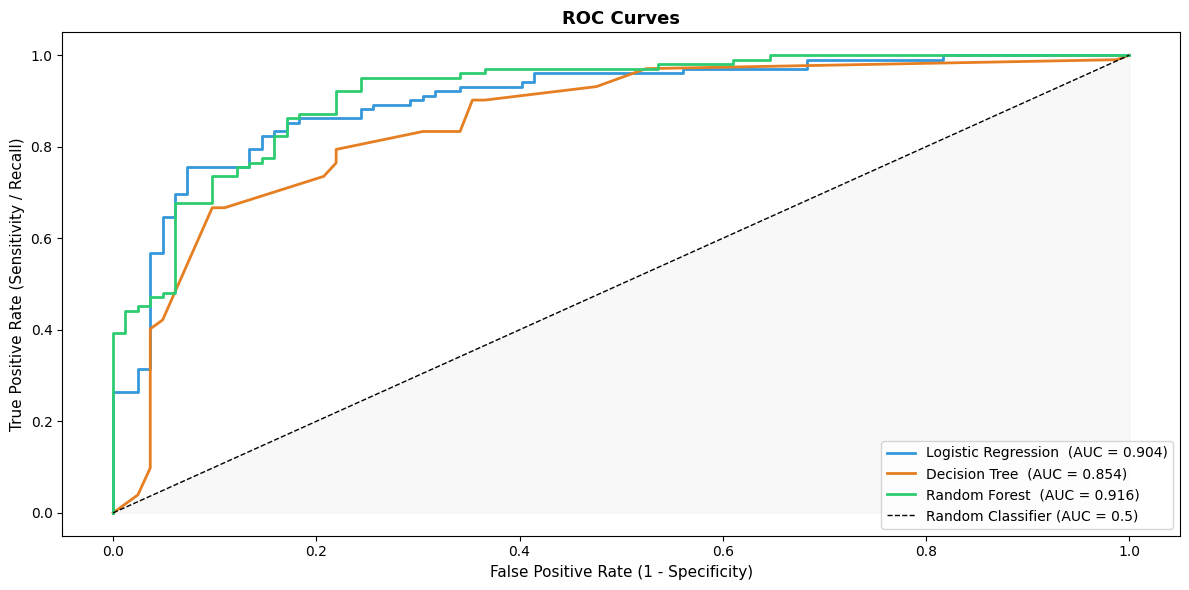

Note: AUC closer to 1.0 = better model. AUC = 0.5 = no better than a coin flip.


In [ ]:
#ROC Curves
models_info = [
    ('Logistic Regression', results[0]['_y_prob'], '#3498db'),
    ('Decision Tree',       results[1]['_y_prob'], '#e67e22'),
    ('Random Forest',       results[2]['_y_prob'], '#2ecc71'),
]

plt.figure(figsize=(12,6))
for name, y_prob, color in models_info:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name}  (AUC = {auc:.3f})')

plt.plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier (AUC = 0.5)')
plt.fill_between([0,1],[0,1], alpha=0.05, color='gray')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
plt.title('ROC Curves', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

print('Note: AUC closer to 1.0 = better model. AUC = 0.5 = no better than a coin flip.')

In [ ]:
#Classification reports
for name, pred in zip(model_names, model_preds):
    print(f'  {name} - Detailed Classification Report')
    print(classification_report(y_test, pred, target_names=['No Disease','Disease']))

  Logistic Regression - Detailed Classification Report
              precision    recall  f1-score   support

  No Disease       0.82      0.79      0.81        82
     Disease       0.84      0.86      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184

  Decision Tree - Detailed Classification Report
              precision    recall  f1-score   support

  No Disease       0.77      0.70      0.73        82
     Disease       0.77      0.83      0.80       102

    accuracy                           0.77       184
   macro avg       0.77      0.76      0.77       184
weighted avg       0.77      0.77      0.77       184

  Random Forest - Detailed Classification Report
              precision    recall  f1-score   support

  No Disease       0.84      0.78      0.81        82
     Disease       0.83      0.88      0.86       102

    accuracy                 



### *   Cross Validation (5-fold)



In [ ]:
#Cross-validation (5-fold - more reliable than a single test split)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, model, X_use in [
    ('Logistic Regression', lr, X_train_scaled),
    ('Decision Tree',       dt, X_train),
    ('Random Forest',       rf, X_train)
]:
    scores = cross_val_score(model, X_use, y_train, cv=cv,
                             scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:22s} | CV ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}')

print('\n± value shows consistency across folds. Lower = more stable.')

Logistic Regression    | CV ROC-AUC: 0.8785 ± 0.0242
Decision Tree          | CV ROC-AUC: 0.7884 ± 0.0365
Random Forest          | CV ROC-AUC: 0.8814 ± 0.0275

± value shows consistency across folds. Lower = more stable.


## VI. Feature Importance

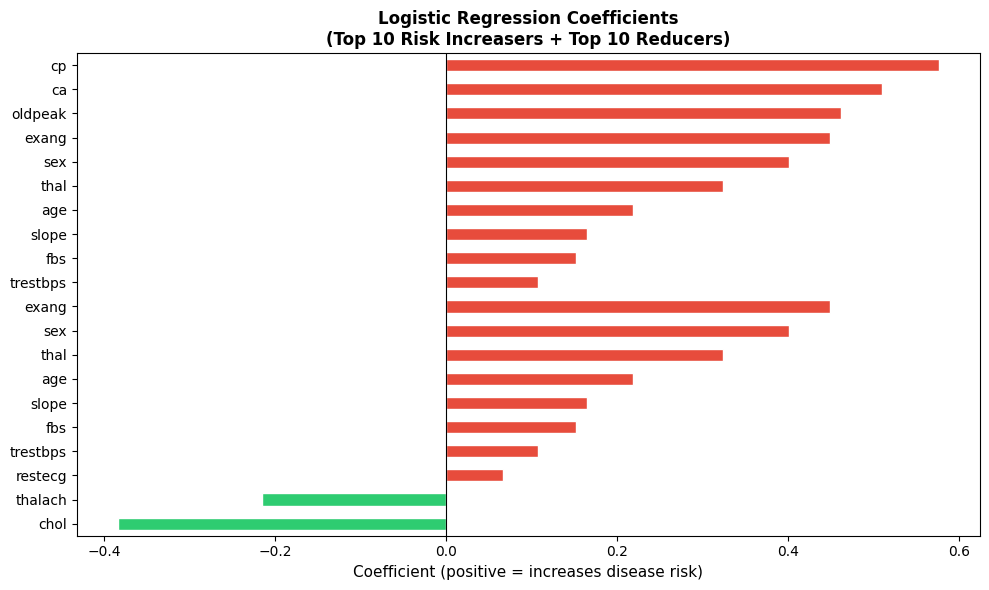

In [ ]:
#Logistic Regression coefficients (odds interpretation)
coef_df = pd.Series(lr.coef_[0], index=X.columns)
coef_df_head = coef_df.sort_values().head(10)
coef_df_tail = coef_df.sort_values().tail(10)
coef_df = pd.concat([coef_df_head, coef_df_tail])
colors  = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef_df.values]

plt.figure(figsize=(10, 6))
coef_df.plot(kind='barh', color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient (positive = increases disease risk)', fontsize=11)
plt.title('Logistic Regression Coefficients\n(Top 10 Risk Increasers + Top 10 Reducers)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

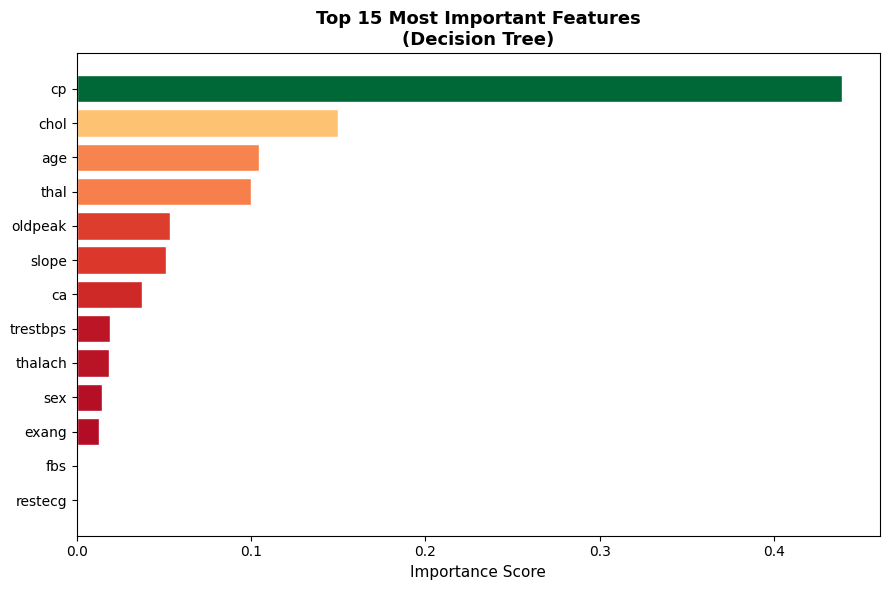

In [ ]:
#Decision Tree feature importances
dt_importances = pd.Series(dt.feature_importances_, index=X.columns)
dt_importances = dt_importances.sort_values(ascending=True).tail(15)

plt.figure(figsize=(9, 6))
plt.barh(dt_importances.index, dt_importances.values,
         color=plt.cm.RdYlGn(dt_importances.values / dt_importances.values.max()),
         edgecolor='white')
plt.xlabel('Importance Score', fontsize=11)
plt.title('Top 15 Most Important Features\n(Decision Tree)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

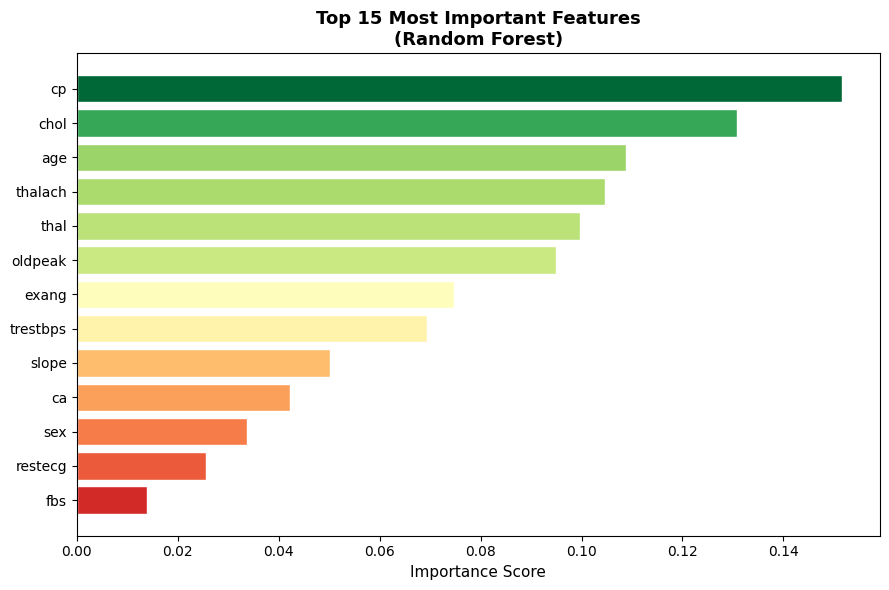


Top 5 features driving heart disease predictions:
cp         0.151549
chol       0.130788
age        0.108755
thalach    0.104559
thal       0.099629
dtype: float64


In [ ]:
#Random Forest feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True).tail(15)

plt.figure(figsize=(9, 6))
bars = plt.barh(importances.index, importances.values,
                color=plt.cm.RdYlGn(importances.values / importances.values.max()),
                edgecolor='white')
plt.xlabel('Importance Score', fontsize=11)
plt.title('Top 15 Most Important Features\n(Random Forest)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 5 features driving heart disease predictions:')
print(importances.tail(5).sort_values(ascending=False))

## VII. Final Summary and Conclusions

In [ ]:
print('FINAL MODEL PERFORMANCE SUMMARY')
print(final.round(4).to_string())
print('-'*65)
print(f'\nBest model by single split ROC-AUC : {best_model_name}')
print(f'Best model by cross-validation AUC : Random Forest (0.8814)')
print(f'\nNote: Cross-validation is the more reliable estimate.')
print(f'Random Forest leads CV (0.8814 vs 0.8785) but the gap is narrow (0.0029).')
print(f'Logistic Regression remains a strong alternative - lower variance (±0.0242 vs ±0.0275) and greater interpretability.')
print(f'Decision Tree is the weakest model under both evaluation methods.')

FINAL MODEL PERFORMANCE SUMMARY
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.8315     0.8381  0.8627    0.8502   0.9035
Decision Tree          0.7717     0.7727  0.8333    0.8019   0.8535
Random Forest          0.8370     0.8333  0.8824    0.8571   0.9164
-----------------------------------------------------------------

Best model by single split ROC-AUC : Random Forest
Best model by cross-validation AUC : Random Forest (0.8814)

Note: Cross-validation is the more reliable estimate.
Random Forest leads CV (0.8814 vs 0.8785) but the gap is narrow (0.0029).
Logistic Regression remains a strong alternative - lower variance (±0.0242 vs ±0.0275) and greater interpretability.
Decision Tree is the weakest model under both evaluation methods.


### Key Findings

**1. Chest pain type is the strongest predictor.**
With a correlation of 0.472, chest pain type (cp) was the top-ranked feature
in both the EDA correlation analysis and all three model feature importance
rankings. This consistency across independent methods confirms it as the most
reliable clinical signal in this dataset.

**2. Cholesterol underperformed expectations.**
Despite being the most widely cited heart disease risk factor, cholesterol
ranked 8th with a correlation of only 0.229. This gap between medical
expectation and data result is a notable finding. Other features such as
exercise-induced angina and maximum heart rate proved far more discriminating
in this dataset.

**3. Random Forest is the best performing model, but only marginally.**
On the single test split, Random Forest led with a ROC-AUC of 0.9164 versus
Logistic Regression at 0.9035. Cross-validation confirmed Random Forest as the
stronger model at 0.8814 versus 0.8785, but the gap is only 0.0029, which is
very narrow. Logistic Regression remains a strong alternative because it is
more stable (±0.0242 vs ±0.0275) and its predictions are fully explainable. An important consideration in clinical settings where doctors need to understand
and trust a prediction.

**4. Recall is the most critical metric for this problem.**
A False Negative predicting a sick patient as healthy is the most
dangerous outcome in medical screening. Random Forest achieved a Recall of
0.88 for the Disease class, meaning it correctly identified 88% of actual
heart disease patients. Logistic Regression achieved 0.86. The remaining
12% and 14% respectively represent missed diagnoses that would require
further attention in real clinical deployment.

### Next steps to improve
1. **Hyperparameter tuning** - Adjusting the settings of our current models to make sure they are performing at their absolute best. use GridSearchCV to find optimal settings for each model and verify whether the Logistic Regression or Random Forest tie holds after tuning.
2. **Threshold tuning** - lower the decision threshold below 0.5 to
   prioritise Recall and reduce missed diagnoses.
3. **Advanced models** - test XGBoost or LightGBM as a next level of
   complexity beyond Random Forest.
4. **Clinical validation** - work with medical professionals to validate
   predictions on new patient data before any real-world deployment.

# Reference List:



*   Janosi, A., Steinbrunn, W., Pfisterer, M., & Detrano, R. (1988). Heart Disease Data Set. UCI Machine Learning Repository. https://doi.org/10.24432/C52P4X
* Kiuchi, A., Fujita, T., & Yamana, H. (2024). Prediction of heart disease severity using hierarchically-structured machine-learning models with feature space reduction. Proceedings of the 17th International Joint Conference on Biomedical Engineering Systems and Technologies, 662–670. https://doi.org/10.5220/0012436700003657
* Vargas Martin, M. (2024). *classification.py*. Course lecture material, MITS6800.
* Vargas Martin, M. (2024). *ensemble_and_rf.py*. Course lecture material, MITS6800.
* Vargas Martin, M. (2024). *decision_tree_using_pygraphviz.ipynb*. Course lecture material, MITS6800.
* Vargas Martin, M. (2024). *training_models.py*. Course lecture material, MITS6800.
* Vargas Martin, M. (2024).*Lecture_3_In_Class_Exercise_auto_mpg_Decision_Trees_and_PCA_for_release.ipynb*. Course lecture material, MITS6800.
